In [1]:
#Importing Libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import random
from tensorflow.keras import layers,models
from tensorflow.keras.applications import VGG16 #import VGG16 
from tensorflow.keras.applications import DenseNet121 #import DenseNet121
from tensorflow.keras.applications.inception_v3 import InceptionV3 #import inceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import optimizers, losses
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

2026-05-26 14:10:10.064743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779804610.551970      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779804610.653010      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779804611.683636      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779804611.683677      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779804611.683680      22 computation_placer.cc:177] computation placer alr

## Load Dataset

In [2]:
dataset_path = "/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers"

print("Folder exists:", os.path.exists(dataset_path))
print("Classes:", os.listdir(dataset_path))
print(tf.__version__)

Folder exists: True
Classes: ['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']
2.19.0


## Display 2 image from each class

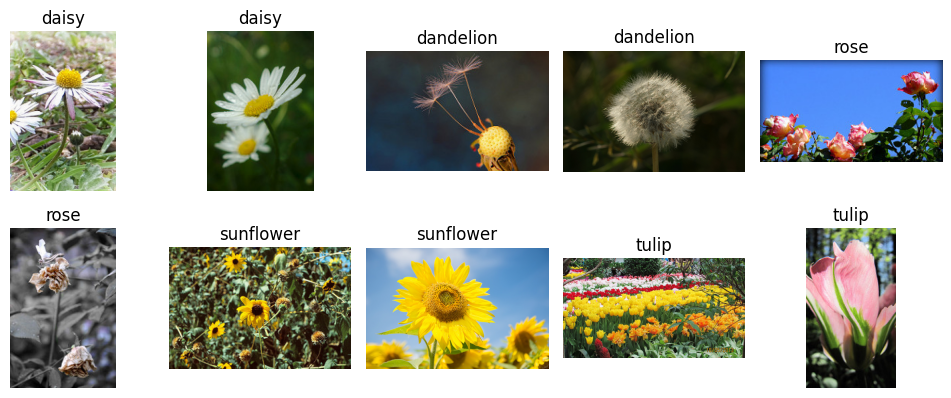

In [3]:
class_names = os.listdir(dataset_path)
class_names.sort()

plt.figure(figsize=(10, 10))

img_count = 1

for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)
    images = os.listdir(class_folder)

    # take first 2 images from each class
    for i in range(2):
        img_path = os.path.join(class_folder, images[i])
        img = Image.open(img_path)

        ax = plt.subplot(len(class_names), 5, img_count)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        plt.title(class_name)
        plt.axis("off")

        img_count += 1

plt.tight_layout()
plt.show()

Image: 3633489595_a037a9b7a4_m.jpg
Shape: (240, 192, 3)
Min pixel: 0
Max pixel: 255
Data type: uint8


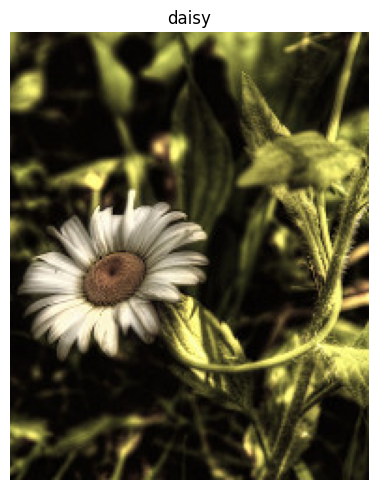

In [4]:
class_names = os.listdir(dataset_path)
class_names.sort()

num_classes = 1
num_images_per_class = 1

selected_classes = random.sample(class_names, num_classes)

plt.figure(figsize=(5, 5))

img_count = 1

for class_name in selected_classes:
    class_folder = os.path.join(dataset_path, class_name)
    images = os.listdir(class_folder)

    selected_images = random.sample(images, num_images_per_class)

    

    for img_name in selected_images:
        img_path = os.path.join(class_folder, img_name)
        
        img = Image.open(img_path)
        img_array = np.array(img)

        # Display pixel information
        print(f"Image: {img_name}")
        print(f"Shape: {img_array.shape}")
        print(f"Min pixel: {img_array.min()}")
        print(f"Max pixel: {img_array.max()}")
        print(f"Data type: {img_array.dtype}")

        plt.subplot(num_classes, num_images_per_class, img_count)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        img_count += 1

plt.tight_layout()
plt.show()

## Image resize

In [5]:
img_height = 224
img_width = 224
batch_size = 32

print(f"Dataset directory: {dataset_path}")
print(f"Target image dimensions: {img_height} x {img_width}")
print(f"Batch size: {batch_size}")

Dataset directory: /kaggle/input/datasets/alxmamaev/flowers-recognition/flowers
Target image dimensions: 224 x 224
Batch size: 32


## Train test and Validation split

#### Checking Full dataset 

In [6]:
full_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

class_names = full_ds.class_names
num_classes = len(class_names)
print("Dataset loaded successfully.")
print("Class names:", class_names)
print("Number of classes:", num_classes)


Found 4317 files belonging to 5 classes.


I0000 00:00:1779804657.893956      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779804657.900061      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Dataset loaded successfully.
Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


In [7]:
# Check the number of batches in the dataset
total_batches = tf.data.experimental.cardinality(full_ds).numpy()
print("Total batches:", total_batches)
# Split the dataset into training, validation, and test sets
train_size = int(0.8 * total_batches)
val_size = int(0.1 * total_batches)
#test_size = total_batches - train_size - val_size
train_ds = full_ds.take(train_size)
temp_ds = full_ds.skip(train_size)

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Total batches: 135


In [8]:
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches   = tf.data.experimental.cardinality(val_ds).numpy()
test_batches  = tf.data.experimental.cardinality(test_ds).numpy()

print("Train batches:", train_batches)
print("Val batches:", val_batches)
print("Test batches:", test_batches)

print("\nimage counts for:")

print("Train images :", train_batches * batch_size)
print("Val images :", val_batches * batch_size)
print("Test images :", test_batches * batch_size)


Train batches: 108
Val batches: 13
Test batches: 14

image counts for:
Train images : 3456
Val images : 416
Test images : 448


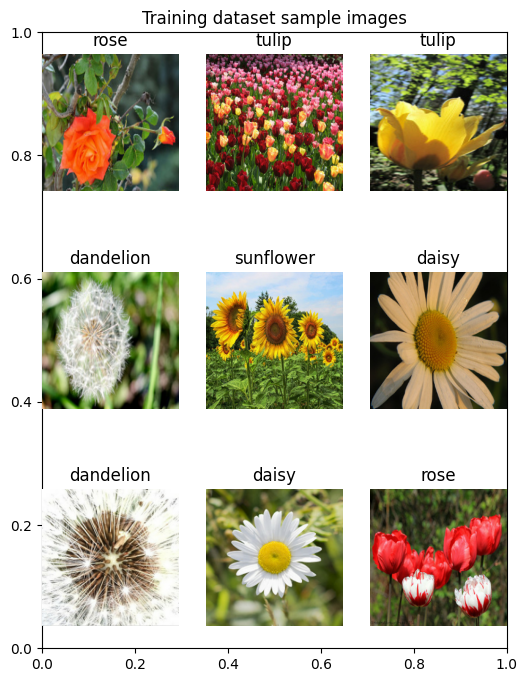

In [9]:
plt.figure(figsize=(6,8))
plt.title("Training dataset sample images")
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # ✅ important
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Data Augmentation

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),        # ~18 degrees
    tf.keras.layers.RandomTranslation(0.1, 0.1), # 10%
    tf.keras.layers.RandomZoom(0.1),
])


## Data Normalization

In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)


In [12]:
# Apply data augmentation and normalization to the training dataset
AUTOTUNE = tf.data.AUTOTUNE #auto-tune the data loading and preprocessing for optimal performance

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(normalization_layer(x), training=True), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)

#this step is to apply normalization to the validation and test datasets without data augmentation, 
# as we want to evaluate the model on unaltered data.
val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)



## Compare Augmented image with original image 

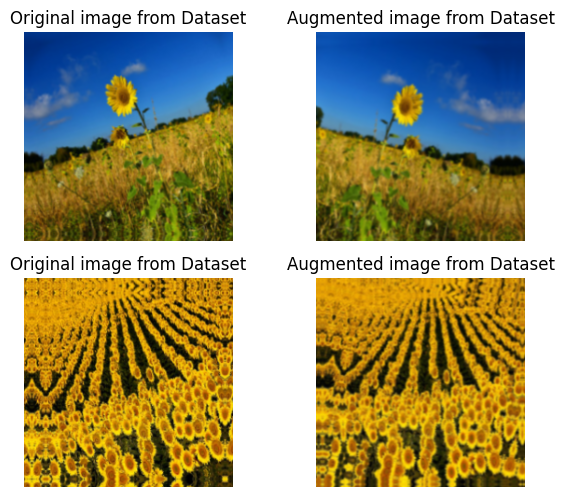

In [13]:
for images, labels in train_ds.take(1):
    original_images = images
    original_labels = labels

augmented_images = data_augmentation(original_images, training=True)

plt.figure(figsize=(6, 10))

for i in range(2):
    # Original
    ax = plt.subplot(4, 2, 2*i + 1)
    plt.imshow(original_images[i])
    plt.title("Original image from Dataset")
    plt.axis("off")

    # Augmented
    ax = plt.subplot(4, 2, 2*i + 2)
    plt.imshow(augmented_images[i])
    plt.title("Augmented image from Dataset")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Ensemble methods
The ensemble model achieved a slight improvement over the best individual model. This is because the individual models share similar architectures and feature extraction patterns, resulting in highly correlated predictions. As a result, the ensemble provides limited additional benefit.

## Load trained model

In [14]:
vgg_model = load_model("/kaggle/input/datasets/jinganteo/kaggledataset-20epoch-model/vgg16_kaggle_flower.keras")
densenet_model = load_model("/kaggle/input/datasets/jinganteo/kaggledataset-20epoch-model/densenet121_kaggle_flower.keras")
inception_model = load_model("/kaggle/input/datasets/jinganteo/kaggledataset-20epoch-model/inceptionV3_kaggle_flower.keras")

print("Models loaded successfully..")

Models loaded successfully..


## Weighted Voting
Generate prediction for each model

In [15]:
vgg_pred = vgg_model.predict(test_ds)
dense_pred = densenet_model.predict(test_ds)
inception_pred = inception_model.predict(test_ds)
#get the predictions for weighted voting from test set

I0000 00:00:1779804706.465215      79 service.cc:152] XLA service 0x79a584003bc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779804706.465265      79 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779804706.465270      79 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779804706.754388      79 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/14 ━━━━━━━━━━━━━━━━━━━━ 3:49 18s/step

I0000 00:00:1779804719.327330      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 19s 739ms/step


In [16]:
#checking individual model performance
y_true = np.concatenate([y for x, y in test_ds], axis=0)

vgg_acc = accuracy_score(y_true, np.argmax(vgg_pred, axis=1))
dense_acc = accuracy_score(y_true, np.argmax(dense_pred, axis=1))
inception_acc = accuracy_score(y_true, np.argmax(inception_pred, axis=1))
print("VGG16:", round(vgg_acc * 100, 2), "%")
print("DenseNet-121:", round(dense_acc * 100, 2), "%")
print("InceptionV3:", round(inception_acc * 100, 2), "%")

VGG16: 83.6 %
DenseNet-121: 88.76 %
InceptionV3: 91.24 %


In [17]:
print(vgg_pred.shape)
print(dense_pred.shape)
print(inception_pred.shape)

(445, 5)
(445, 5)
(445, 5)


#### To implement weighted voting, We need to find the best weight distribution for each model

In [18]:
weight_sets = {
    "VGG16 Dominant": (0.6, 0.2, 0.2),
    "DenseNet Dominant": (0.2, 0.6, 0.2),
    "Inception Dominant": (0.2, 0.2, 0.6),

    "Strong VGG16 Dominant": (0.7, 0.15, 0.15),
    "Strong DenseNet Dominant": (0.15, 0.7, 0.15),
    "Strong Inception Dominant": (0.15, 0.15, 0.7),

    "Balanced Strong Models": (0.1, 0.4, 0.5),
    "Inception Focused": (0.1, 0.2, 0.7),
    "DenseNet + Inception": (0, 0.5, 0.5),

    "DenseNet Heavy + Inception": (0.0, 0.8, 0.2),
    "Inception Heavy + DenseNet": (0.0, 0.2, 0.8),
    "VGG16 Heavy + Low DenseNet + Low Inception": (0.8, 0.1, 0.1)
}
results = []

for name, (w_vgg, w_dense, w_inception) in weight_sets.items():

    ensemble_pred = (
        w_vgg * vgg_pred +
        w_dense * dense_pred +
        w_inception * inception_pred
    )
    #Final predicted class 
    y_pred_ensemble = np.argmax(ensemble_pred, axis=1)
    #Calculate accuracy for the ensemble predictions
    ensemble_acc = accuracy_score(y_true, y_pred_ensemble)

    results.append([
        name,
        w_vgg,
        w_dense,
        w_inception,
        round(ensemble_acc * 100, 2)
    ])

# Create DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Ensemble Strategy",
        "VGG16 Weight",
        "DenseNet-121 Weight",
        "InceptionV3 Weight",
        "Accuracy (%)"
    ]
)

# Sort by best accuracy
results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

print("\n\t\t\t========== Weighted Voting Comparison ==========\n")

print(results_df)


			========== Weighted Voting Comparison ==========

                             Ensemble Strategy  VGG16 Weight  DenseNet-121 Weight  InceptionV3 Weight  Accuracy (%)
0                           Inception Dominant          0.20                 0.20                0.60         92.13
1                    Strong Inception Dominant          0.15                 0.15                0.70         92.13
2                            Inception Focused          0.10                 0.20                0.70         92.13
3                   Inception Heavy + DenseNet          0.00                 0.20                0.80         91.91
4                         DenseNet + Inception          0.00                 0.50                0.50         91.69
5                       Balanced Strong Models          0.10                 0.40                0.50         91.24
6                            DenseNet Dominant          0.20                 0.60                0.20         91.24
7                 

In [19]:
# DISPLAY BEST ENSEMBLE STRATEGY
best_result = results_df.iloc[0]

print("\n========== Best Ensemble Strategy ==========\n")

print(f"Strategy            : {best_result['Ensemble Strategy']}")
print(f"VGG16 Weight        : {best_result['VGG16 Weight']}")
print(f"DenseNet121 Weight  : {best_result['DenseNet-121 Weight']}")
print(f"InceptionV3 Weight  : {best_result['InceptionV3 Weight']}")
print(f"Best Accuracy       : {best_result['Accuracy (%)']}%")


========== Best Ensemble Strategy ==========

Strategy            : Inception Dominant
VGG16 Weight        : 0.2
DenseNet121 Weight  : 0.2
InceptionV3 Weight  : 0.6
Best Accuracy       : 92.13%


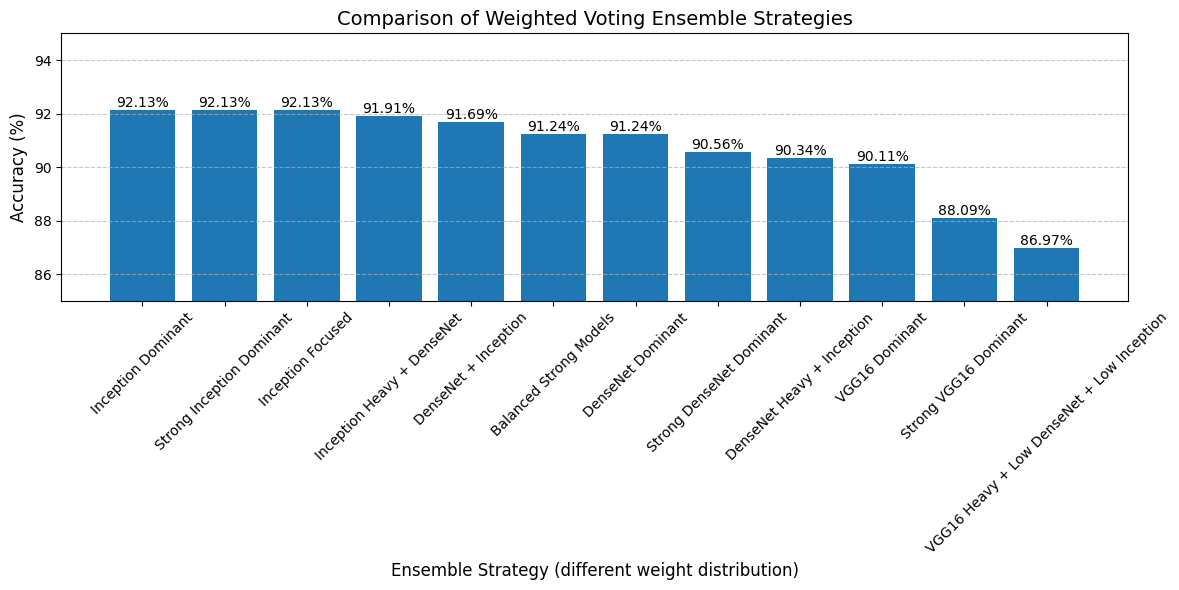

In [20]:
# Plot figure
plt.figure(figsize=(12,6))

# Bar chart
bars = plt.bar(
    results_df["Ensemble Strategy"],
    results_df["Accuracy (%)"]
)

# Labels and title
plt.xlabel("Ensemble Strategy (different weight distribution)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Comparison of Weighted Voting Ensemble Strategies", fontsize=14)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Set y-axis range for better visualization
plt.ylim(85, 95)

# Add accuracy labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}%",
        ha='center',
        fontsize=10
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tight layout
plt.tight_layout()

# Show graph
plt.show()

In [21]:
#build the final ensemble model using the best weights from the weighted voting comparison
we_ensemble_pred = (
    0.2 * vgg_pred +
    0.2 * dense_pred +
    0.6 * inception_pred
)
y_pred_final_We = np.argmax(we_ensemble_pred, axis=1)

In [22]:
print("\n========== Classification Report For Weighted Voting ==========\n")
print(classification_report(
    y_true,
    y_pred_final_We,
    target_names=class_names
))
final_accuracy_we = accuracy_score(
    y_true,
    y_pred_final_We
)
#we = weighted voting
# Convert to percentage
final_accuracy_percentage_we = final_accuracy_we * 100
print(f"\nFinal Weighted Voting Test Accuracy : {final_accuracy_percentage_we:.2f}%")


========== Classification Report For Weighted Voting ==========

              precision    recall  f1-score   support

       daisy       0.91      0.91      0.91        68
   dandelion       0.94      0.95      0.95       120
        rose       0.92      0.87      0.90        69
   sunflower       0.91      0.93      0.92        80
       tulip       0.91      0.93      0.92       108

    accuracy                           0.92       445
   macro avg       0.92      0.92      0.92       445
weighted avg       0.92      0.92      0.92       445


Final Weighted Voting Test Accuracy : 92.13%


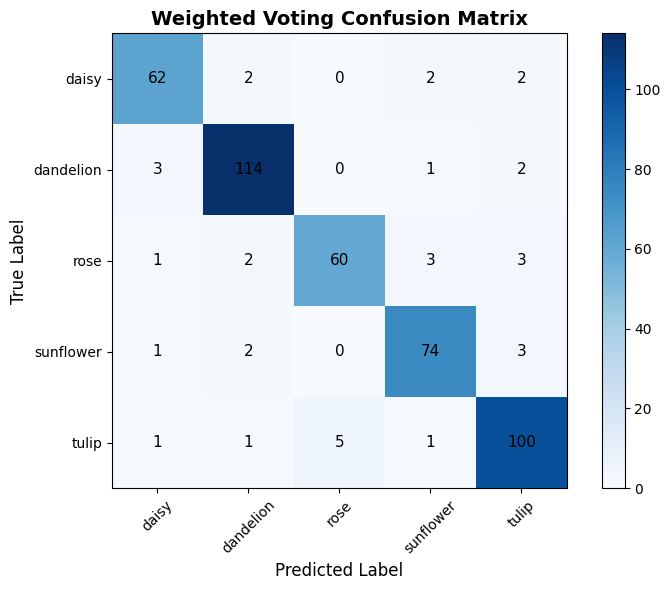

In [23]:
cm = confusion_matrix(
    y_true,
    y_pred_final_We
)
plt.figure(figsize=(8,6))

plt.imshow(cm, cmap="Blues")
# Title and labels
plt.title(
    "Weighted Voting Confusion Matrix",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "True Label",
    fontsize=12
)

# Tick labels using flower names
plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## Soft Voting

In [24]:
# SOFT VOTING
soft_voting_weights = (0.33, 0.33, 0.33)

soft_pred = (
    soft_voting_weights[0] * vgg_pred +
    soft_voting_weights[1] * dense_pred +
    soft_voting_weights[2] * inception_pred
)

y_pred_soft = np.argmax(soft_pred, axis=1)

soft_voting_acc = accuracy_score(
    y_true,
    y_pred_soft
)

print("\n========== Soft Voting Result ==========\n")

print(f"Soft Voting Accuracy : {soft_voting_acc * 100:.2f}%")


========== Soft Voting Result ==========

Soft Voting Accuracy : 92.13%


## Stacking
Stacking (Stacked Generalization) is an advanced ensemble learning method that combines multiple base models using a Machine Learning Meta-Classifier.

Instead of relying on heuristic weighted voting, stacking trains a supervised learning model to learn how to optimally combine the predicted class probabilities of the base models (VGG16, DenseNet121, InceptionV3) to maximize classification accuracy.

Training Stacking Features:
To avoid data leakage, we:
Generate probability predictions for all three baseline models on the validation dataset (val_ds).
Concatenate these probability distributions as features (Xval). Each sample has 5 classes x 3 models=15features.
Train a meta-classifier (e.g., Logistic Regression, Random Forest, SVC) on these validation features to learn how to predict the true validation labels.
Evaluate the trained meta-classifier on the pre-computed test set predictions (Xtest).

In [25]:
# Generate validation set predictions to construct training features for the meta-classifier
print("Generating validation set predictions for Stacking meta-training...")
y_val_true = np.concatenate([y for x, y in val_ds], axis=0)
vgg_val_pred = vgg_model.predict(val_ds)
dense_val_pred = densenet_model.predict(val_ds)
inception_val_pred = inception_model.predict(val_ds)

# Concatenate probability distributions horizontally to form features (shape: [num_samples, 15])
X_val_meta = np.hstack([vgg_val_pred, dense_val_pred, inception_val_pred])
print("Validation Stacking features shape:", X_val_meta.shape)
print("Validation labels shape:", y_val_true.shape)

Generating validation set predictions for Stacking meta-training...
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
Validation Stacking features shape: (416, 15)
Validation labels shape: (416,)


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Construct test features from the pre-computed baseline model predictions
X_test_meta = np.hstack([vgg_pred, dense_pred, inception_pred])

# Define meta-classifiers to compare
meta_classifiers = {
    "Stacking (Logistic Regression)": LogisticRegression(max_iter=1000, random_state=42),
    "Stacking (Random Forest)": RandomForestClassifier(n_estimators=100, random_state=42),
    "Stacking (Support Vector Machine)": SVC(probability=True, random_state=42),
    "Stacking (Gradient Boosting)": GradientBoostingClassifier(random_state=42)
}
# to compare which is the best meta-classifier and implemented as a stacking ensemble model
stacking_results = {}
print("\n========== Training Meta-Classifiers for Stacking ==========\n")
for name, clf in meta_classifiers.items():
    clf.fit(X_val_meta, y_val_true)
    y_pred_stack = clf.predict(X_test_meta)
    acc = accuracy_score(y_true, y_pred_stack)
    stacking_results[name] = (clf, acc, y_pred_stack)
    print(f"{name} Test Accuracy : {acc * 100:.2f}%")


========== Training Meta-Classifiers for Stacking ==========

Stacking (Logistic Regression) Test Accuracy : 92.13%
Stacking (Random Forest) Test Accuracy : 92.58%
Stacking (Support Vector Machine) Test Accuracy : 91.69%
Stacking (Gradient Boosting) Test Accuracy : 92.81%



========== Stacking Ensemble Comparison ==========

                     Meta-Classifier  Accuracy (%)
3       Stacking (Gradient Boosting)         92.81
1           Stacking (Random Forest)         92.58
0     Stacking (Logistic Regression)         92.13
2  Stacking (Support Vector Machine)         91.69


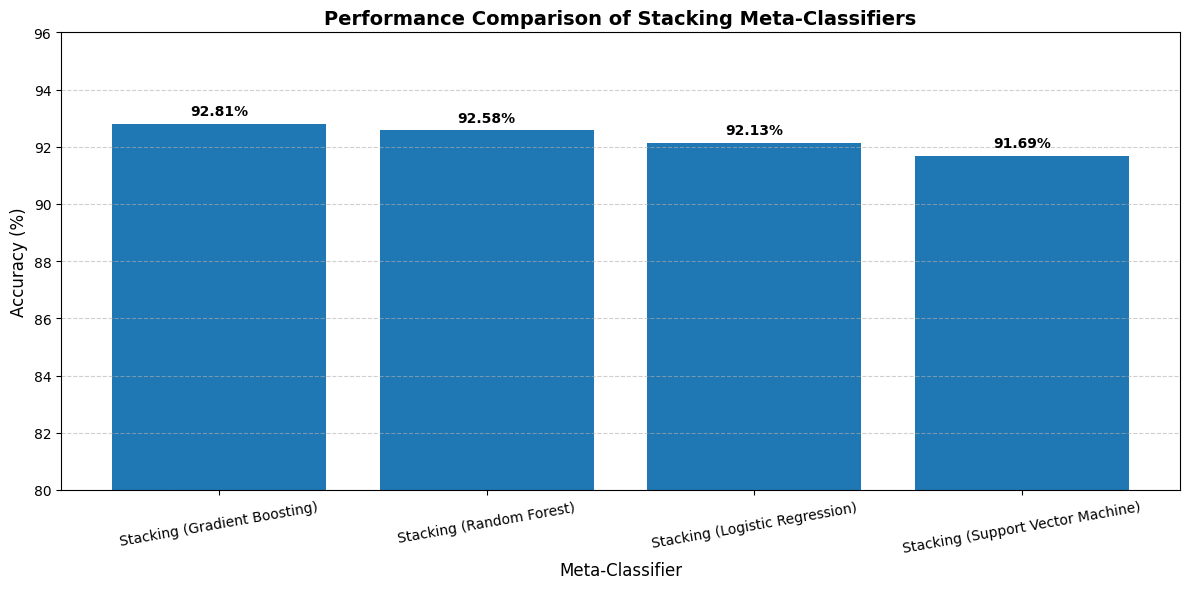

In [27]:
stacking_comparison_df = pd.DataFrame({

    "Meta-Classifier": list(stacking_results.keys()),

    "Accuracy (%)": [
        round(acc * 100, 2)
        for (_, acc, _) in stacking_results.values()
    ]
})

# Sort results from highest to lowest accuracy
stacking_comparison_df = stacking_comparison_df.sort_values(
    by="Accuracy (%)",
    ascending=False
)

# =========================
# DISPLAY TABLE
# =========================

print("\n========== Stacking Ensemble Comparison ==========\n")

print(stacking_comparison_df)
# =========================
# STACKING RESULTS VISUALIZATION
# =========================

plt.figure(figsize=(12,6))

bars = plt.bar(
    stacking_comparison_df["Meta-Classifier"],
    stacking_comparison_df["Accuracy (%)"]
)

# Add accuracy labels above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.2f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Title
plt.title(
    "Performance Comparison of Stacking Meta-Classifiers",
    fontsize=14,
    fontweight='bold'
)

# Axis labels
plt.xlabel(
    "Meta-Classifier",
    fontsize=12
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=12
)

# Rotate x-axis labels
plt.xticks(
    rotation=10,
    fontsize=10
)

# Better visualization range
plt.ylim(80, 96)

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

# Tight layout
plt.tight_layout()

# Show graph
plt.show()

In [28]:
# Select the best meta-classifier based on test performance
best_stacking_name = max(stacking_results, key=lambda k: stacking_results[k][1])
best_clf, stacking_accuracy, y_pred_stacking = stacking_results[best_stacking_name]

print(f"\n========== Best Stacking Strategy ==========\n")
print(f"Meta-Classifier : {best_stacking_name}")
print(f"Accuracy        : {stacking_accuracy * 100:.2f}%")

print("\n========== Classification Report For Stacking ==========\n")
print(classification_report(y_true, y_pred_stacking, target_names=class_names))
stacking_accuracy_percentage = stacking_accuracy * 100


========== Best Stacking Strategy ==========

Meta-Classifier : Stacking (Gradient Boosting)
Accuracy        : 92.81%

========== Classification Report For Stacking ==========

              precision    recall  f1-score   support

       daisy       0.95      0.91      0.93        68
   dandelion       0.94      0.97      0.95       120
        rose       0.88      0.91      0.89        69
   sunflower       0.94      0.95      0.94        80
       tulip       0.93      0.89      0.91       108

    accuracy                           0.93       445
   macro avg       0.93      0.93      0.93       445
weighted avg       0.93      0.93      0.93       445



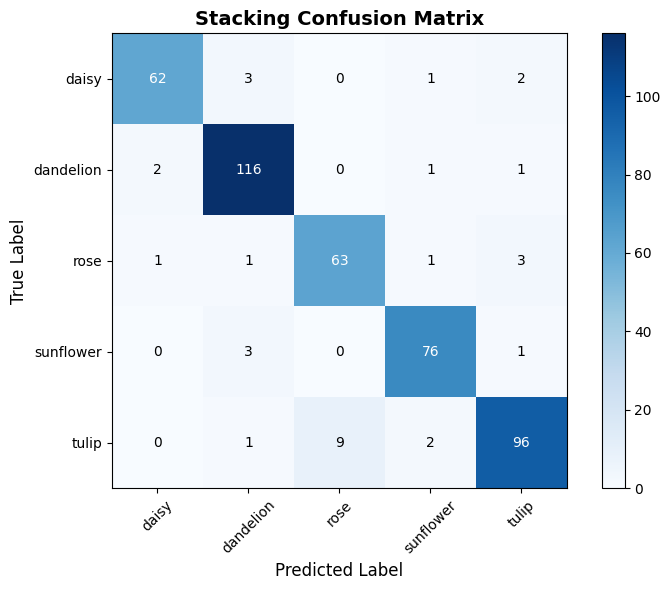

In [29]:
# Plot Stacking Confusion Matrix
cm_stacking = confusion_matrix(y_true, y_pred_stacking)
plt.figure(figsize=(8,6))
plt.imshow(cm_stacking, cmap="Blues")
plt.title(f"Stacking Confusion Matrix", fontsize=14, fontweight='bold')
plt.colorbar()

plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm_stacking[i, j], ha="center", va="center", 
                 color="white" if cm_stacking[i, j] > cm_stacking.max()/2 else "black")

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

## Final Comparison


========== Final Model Comparison ==========

             Model  Accuracy (%)
0            VGG16         83.60
1      DenseNet121         88.76
2      InceptionV3         91.24
3      Soft Voting         92.13
4  Weighted Voting         92.13
5        Stacking          92.81


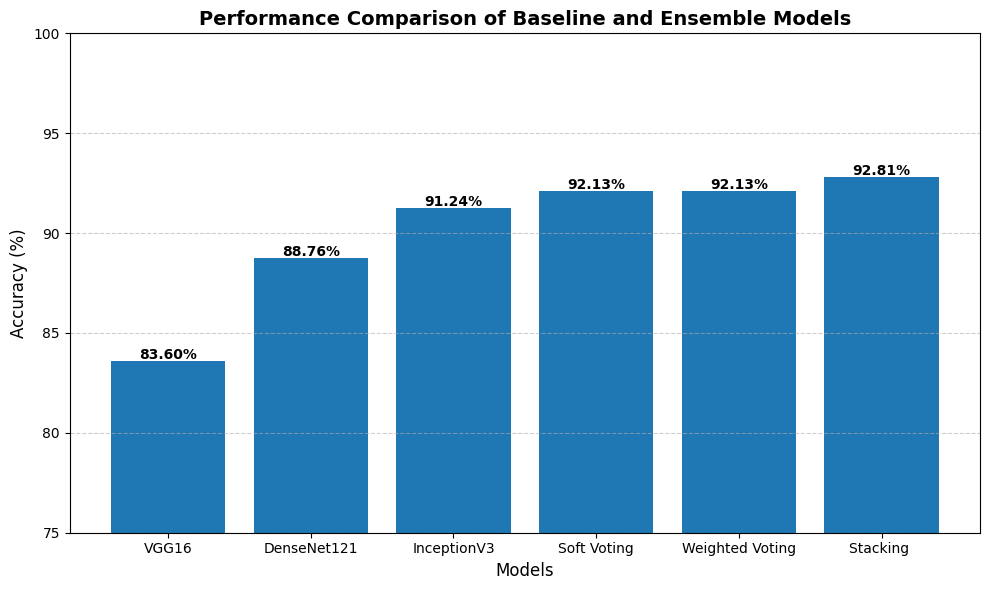

In [30]:
# FINAL MODEL COMPARISON
comparison_results = {
    "Model": [
        "VGG16",
        "DenseNet121",
        "InceptionV3",
        "Soft Voting",
        "Weighted Voting",
        "Stacking "
    ],
    "Accuracy (%)": [
        round(vgg_acc * 100, 2),
        round(dense_acc * 100, 2),
        round(inception_acc * 100, 2),
        round(soft_voting_acc * 100, 2),
        round(final_accuracy_percentage_we, 2),
        round(stacking_accuracy_percentage, 2)
    ]
}

# CREATE DATAFRAME

comparison_df = pd.DataFrame(comparison_results)
# DISPLAY TABLE
print("\n========== Final Model Comparison ==========\n")

print(comparison_df)

plt.figure(figsize=(10,6))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}%",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Performance Comparison of Baseline and Ensemble Models",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    "Models",
    fontsize=12
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=12
)

# Better visualization range
plt.ylim(75, 100)

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()


plt.show()